# 04 — Vision (Multimodal)

`gemma4:e4b` is a multimodal model — it processes images and text together in a single
prompt. This notebook demonstrates structured extraction from three synthetic Contoso
assets, all without leaving the machine.

| Image | Task | Ground truth |
| --- | --- | --- |
| `invoice_sample.jpg` | Extract vendor, total, VAT | Acme Cloud Ltd · £4,832.00 · £805.33 |
| `org_chart.png` | List CTO's direct reports | Alice Chen · Bob Patel · Carol Osei · Dan Müller |
| `dashboard_screenshot.png` | Read attrition KPI | 4.2 % |

The final section shows graceful degradation when a **non-vision model** receives an image.

> **API**: images are passed as raw bytes via `images=[bytes]` in the message dict.
> No Pillow required — the stdlib `pathlib` is enough.

In [1]:
from pathlib import Path

from utils.helpers import check_model_available, check_ollama_running

VISION_MODEL = "gemma4:e4b"
FALLBACK_MODEL = "mistral:7b"       # non-vision, used in the error-handling section
VISION_DIR = Path("data/vision")

if not check_ollama_running():
    raise RuntimeError("Ollama is not running. Start it with: ollama serve")

if not check_model_available(VISION_MODEL):
    raise RuntimeError(
        f"'{VISION_MODEL}' not found locally.\n"
        f"Pull it with: ollama pull {VISION_MODEL}"
    )

print(f"✓ Vision model: {VISION_MODEL}")

# Pre-load image bytes — passed directly to ollama, no conversion needed
INVOICE = (VISION_DIR / "invoice_sample.jpg").read_bytes()
ORG_CHART = (VISION_DIR / "org_chart.png").read_bytes()
DASHBOARD = (VISION_DIR / "dashboard_screenshot.png").read_bytes()

print(f"✓ Images loaded: invoice {len(INVOICE):,} B  "
      f"| org_chart {len(ORG_CHART):,} B  "
      f"| dashboard {len(DASHBOARD):,} B")

✓ Vision model: gemma4:e4b
✓ Images loaded: invoice 107,215 B  | org_chart 89,625 B  | dashboard 149,250 B


## 1. Vendor invoice — structured extraction

Ask the model to extract vendor name, invoice total, and VAT amount from the invoice image.
We combine `images` with `format=schema` so the output is immediately parseable.

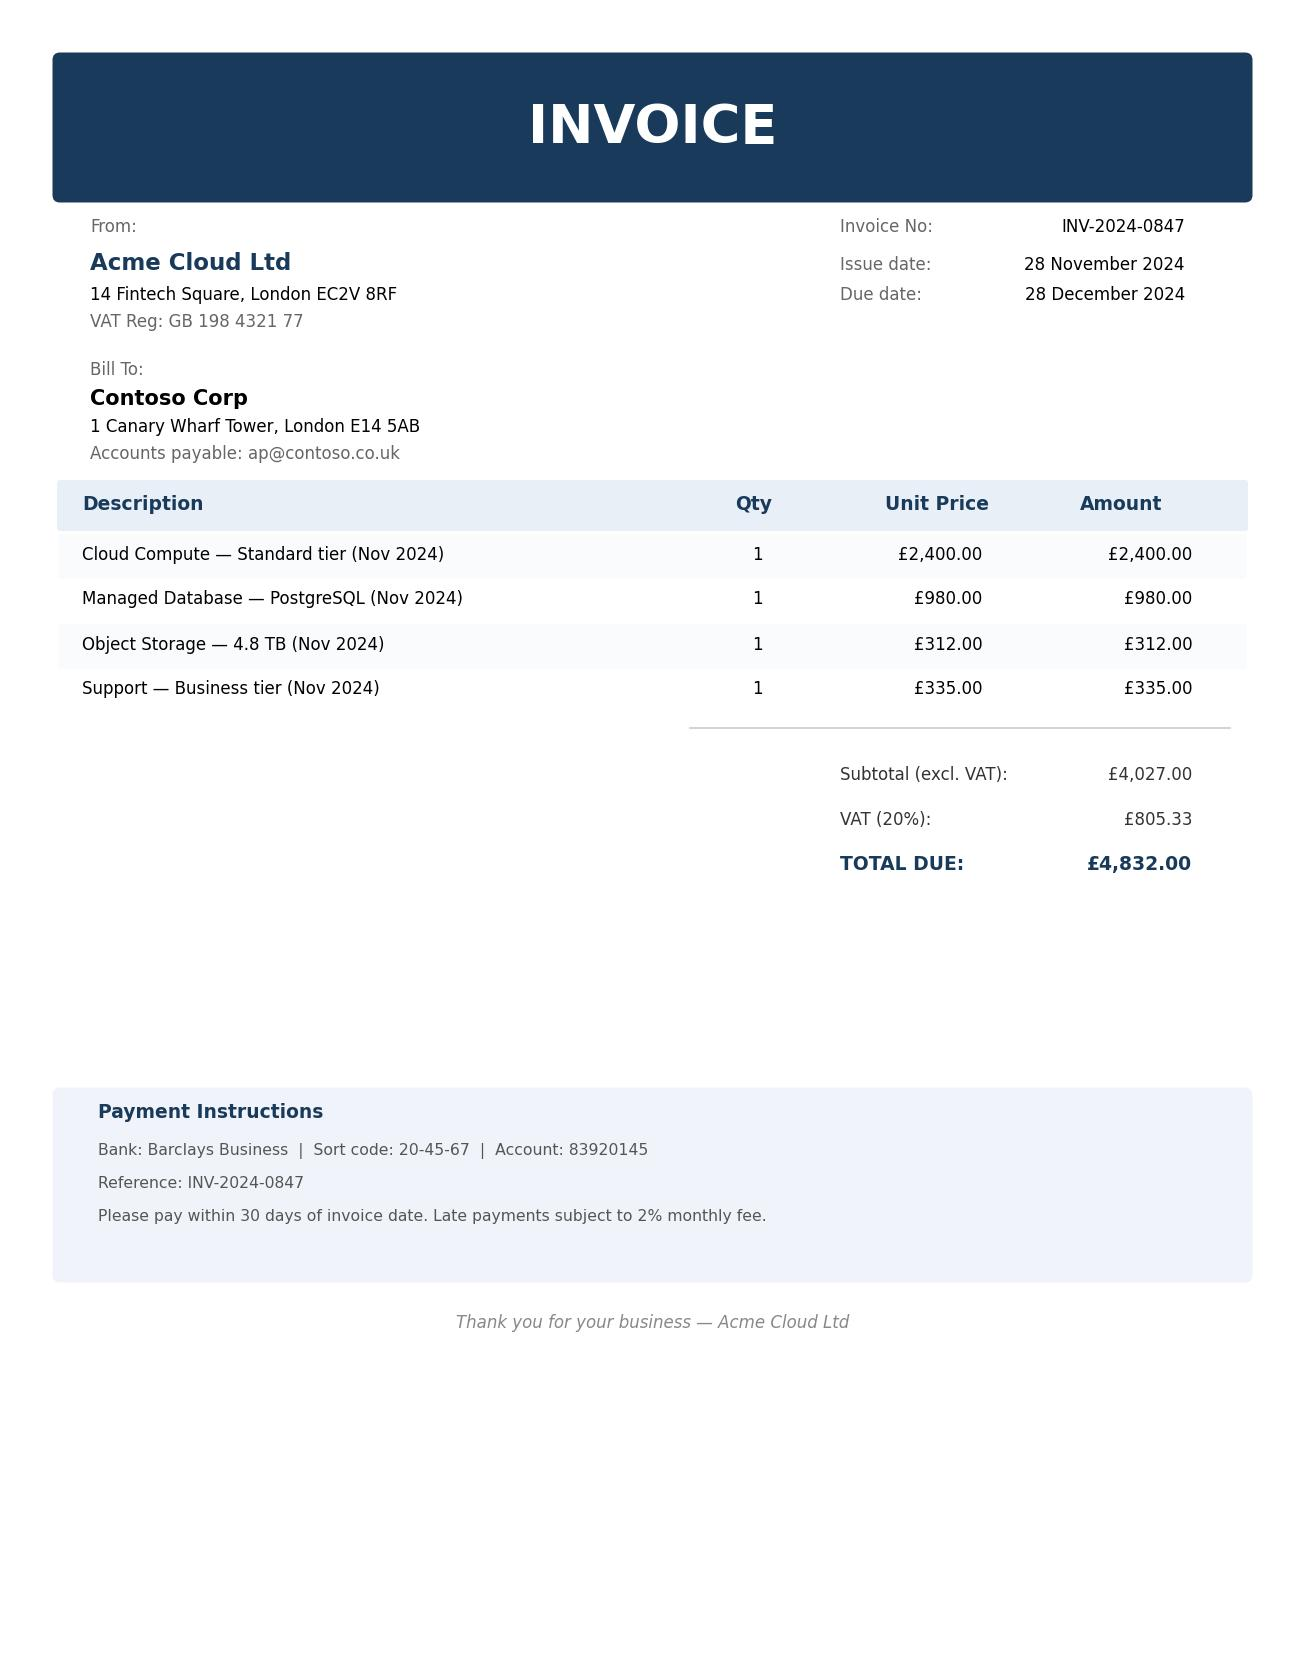

In [2]:
from IPython.display import Image as IPImage
from IPython.display import display
from ollama import chat
from pydantic import BaseModel

display(IPImage(data=INVOICE, width=600))


In [3]:
class InvoiceData(BaseModel):
    vendor_name: str
    invoice_number: str
    total_amount_gbp: float
    vat_amount_gbp: float


response = chat(
    model=VISION_MODEL,
    messages=[{
        "role": "user",
        "content": (
            "Extract the vendor name, invoice number, total amount due (GBP), "
            "and VAT amount (GBP) from this invoice. Numbers only, no currency symbols."
        ),
        "images": [INVOICE],
    }],
    format=InvoiceData.model_json_schema(),
    options={"temperature": 0},
)

invoice = InvoiceData.model_validate_json(response.message.content)

print("Extracted:")
print(f"  Vendor:         {invoice.vendor_name}")
print(f"  Invoice no:     {invoice.invoice_number}")
print(f"  Total (GBP):    £{invoice.total_amount_gbp:,.2f}")
print(f"  VAT (GBP):      £{invoice.vat_amount_gbp:,.2f}")

# Ground-truth check
assert invoice.vendor_name == "Acme Cloud Ltd", (
    f"vendor mismatch: {invoice.vendor_name}"
)
assert invoice.total_amount_gbp == 4832.00, (
    f"total mismatch: {invoice.total_amount_gbp}"
)
assert invoice.vat_amount_gbp == 805.33, f"VAT mismatch: {invoice.vat_amount_gbp}"
print("\n✓ All values match ground truth")

Extracted:
  Vendor:         Acme Cloud Ltd
  Invoice no:     INV-2024-0847
  Total (GBP):    £4,832.00
  VAT (GBP):      £805.33

✓ All values match ground truth


## 2. Org chart — relationship extraction

From the org chart image, ask the model to identify the CTO's name and list all
employees who report directly to them (Level 1).

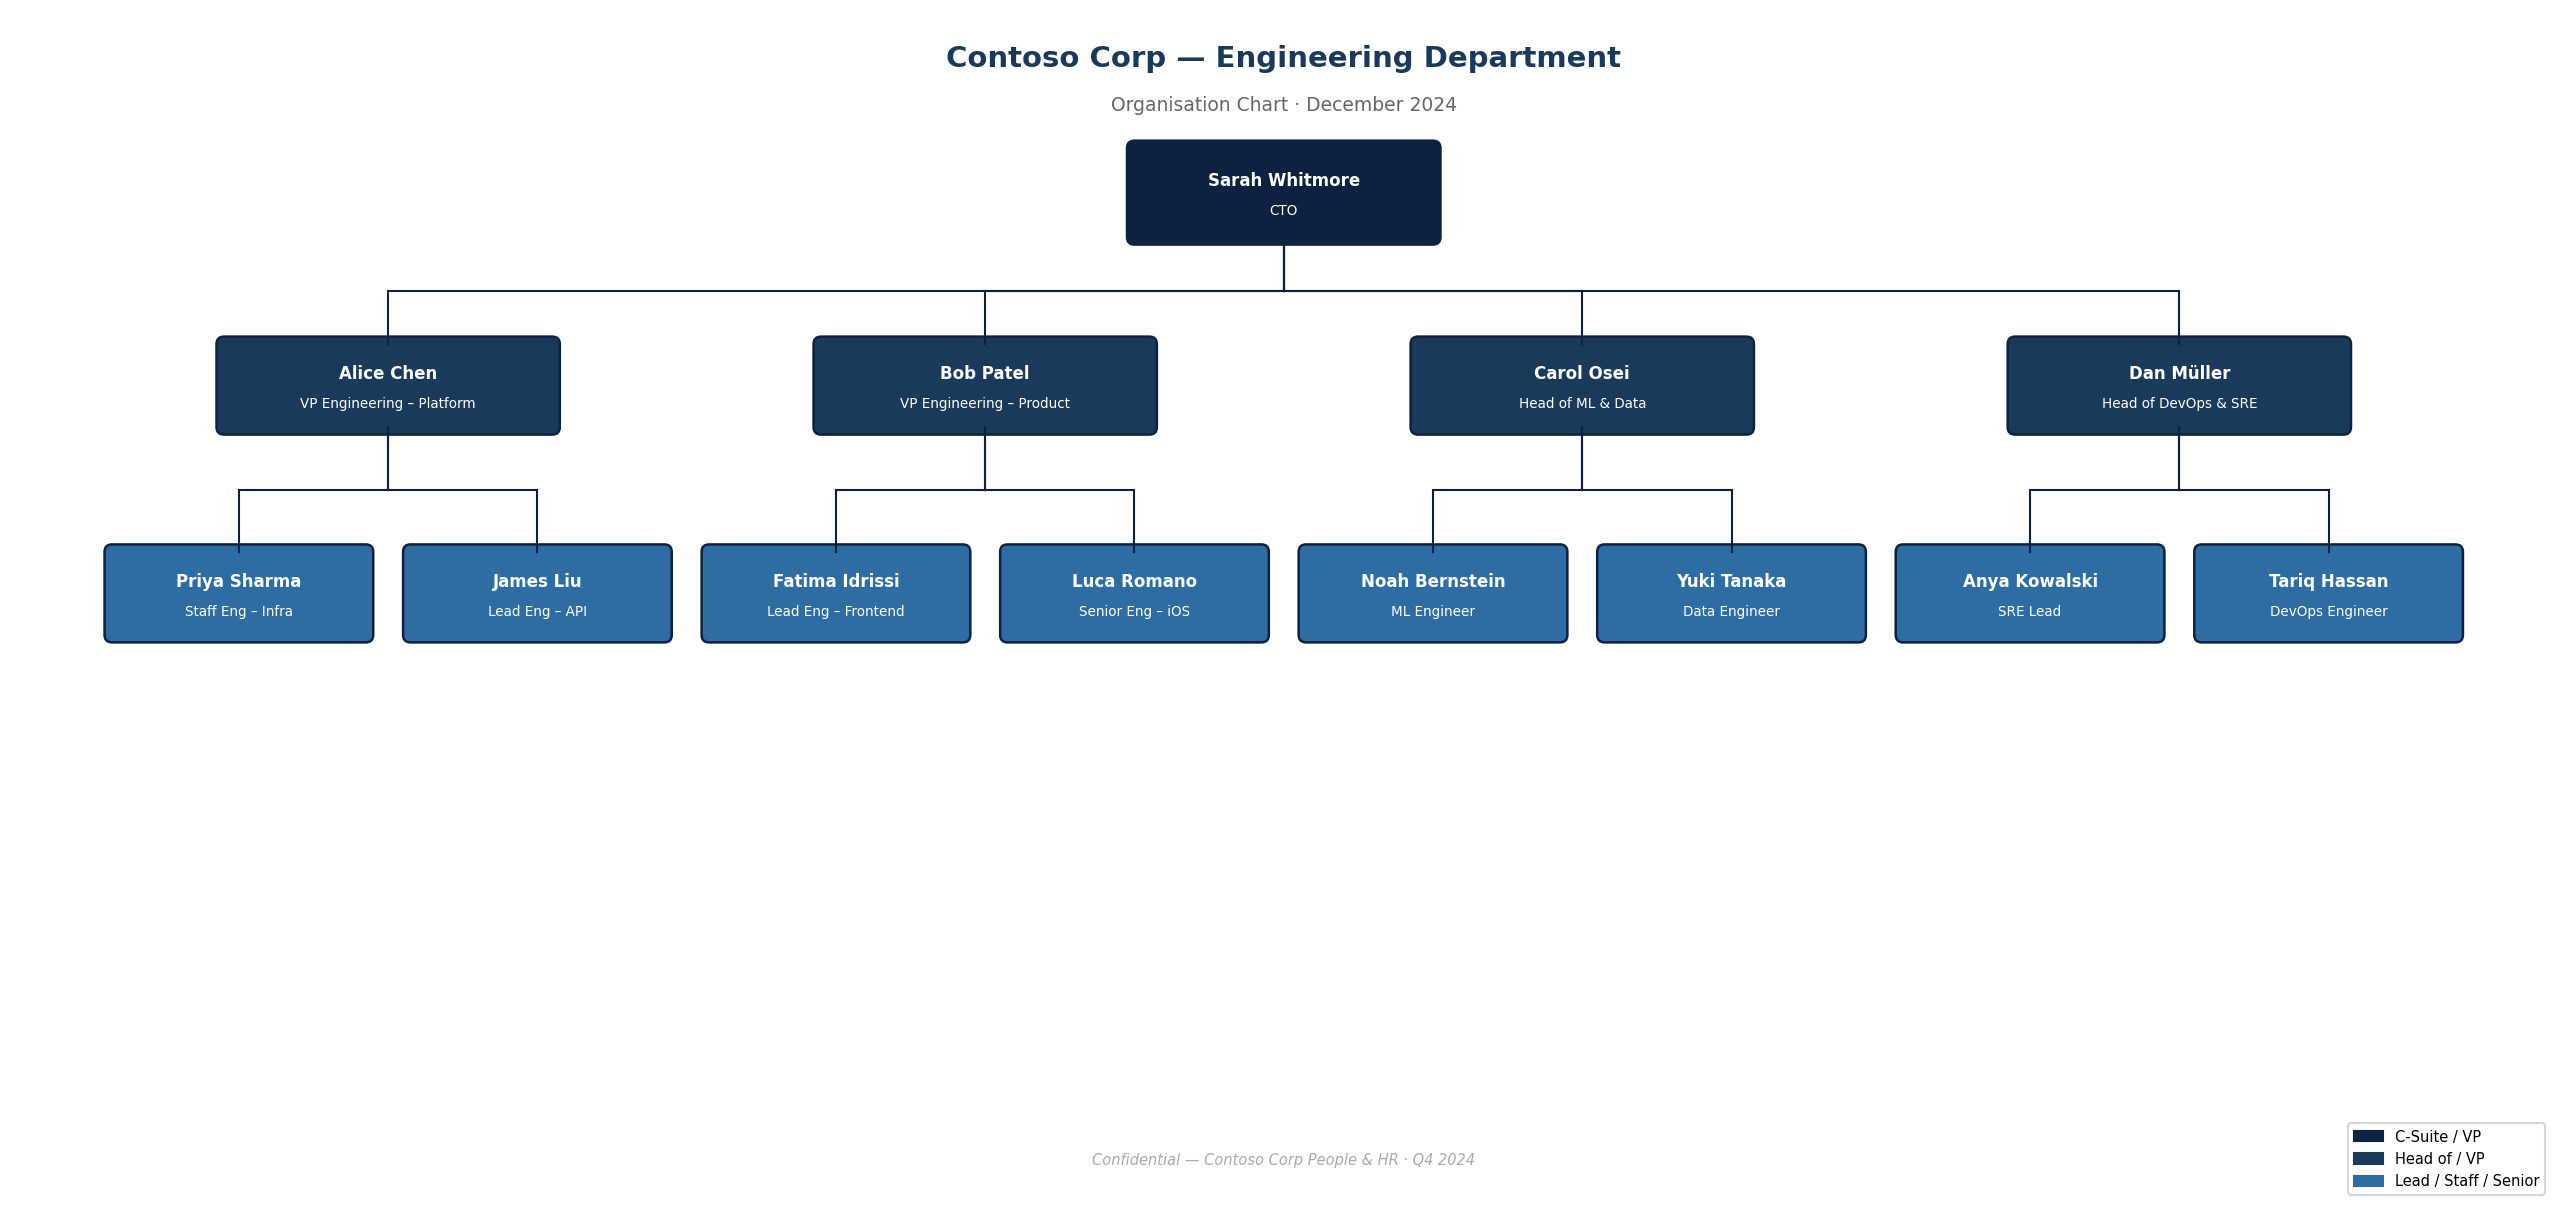

In [4]:
display(IPImage(data=ORG_CHART, width=700))


In [7]:
class OrgChartData(BaseModel):
    cto_name: str
    direct_reports: list[str]


response = chat(
    model=VISION_MODEL,
    messages=[{
        "role": "user",
        "content": (
            "From this org chart, extract the CTO's full name and the full names "
            "of all employees who report directly to the CTO (Level 1 only, "
            "not Level 2 reports)."
        ),
        "images": [ORG_CHART],
    }],
    format=OrgChartData.model_json_schema(),
    options={"temperature": 0},
)

org = OrgChartData.model_validate_json(response.message.content)

print(f"CTO: {org.cto_name}")
print("Direct reports:")
for name in org.direct_reports:
    print(f"  • {name}")

# Ground-truth check
EXPECTED_CTO = "Sarah Whitmore"
EXPECTED_REPORTS = {"Alice Chen", "Bob Patel", "Carol Osei", "Dan Müller"}
extracted_reports = {n.strip() for n in org.direct_reports}

cto_ok = org.cto_name == EXPECTED_CTO
reports_ok = extracted_reports == EXPECTED_REPORTS

print(f"\nCTO name:       {'✓' if cto_ok else '✗'} (expected: {EXPECTED_CTO})")
mark = '✓' if reports_ok else '✗'
print(f"Direct reports: {mark} (expected: {sorted(EXPECTED_REPORTS)})")
if not reports_ok:
    print(f"  Got: {sorted(extracted_reports)}")

CTO: Sarah Whitmore
Direct reports:
  • Alice Chen
  • Rob Patel
  • Carol Osei
  • Dan Müller

CTO name:       ✓ (expected: Sarah Whitmore)
Direct reports: ✗ (expected: ['Alice Chen', 'Bob Patel', 'Carol Osei', 'Dan Müller'])
  Got: ['Alice Chen', 'Carol Osei', 'Dan Müller', 'Rob Patel']


## 3. HR dashboard — KPI reading

Ask the model to read numeric KPI values from a synthetic dashboard screenshot.
This tests OCR-like capability on UI elements — a common enterprise document-processing
use case.

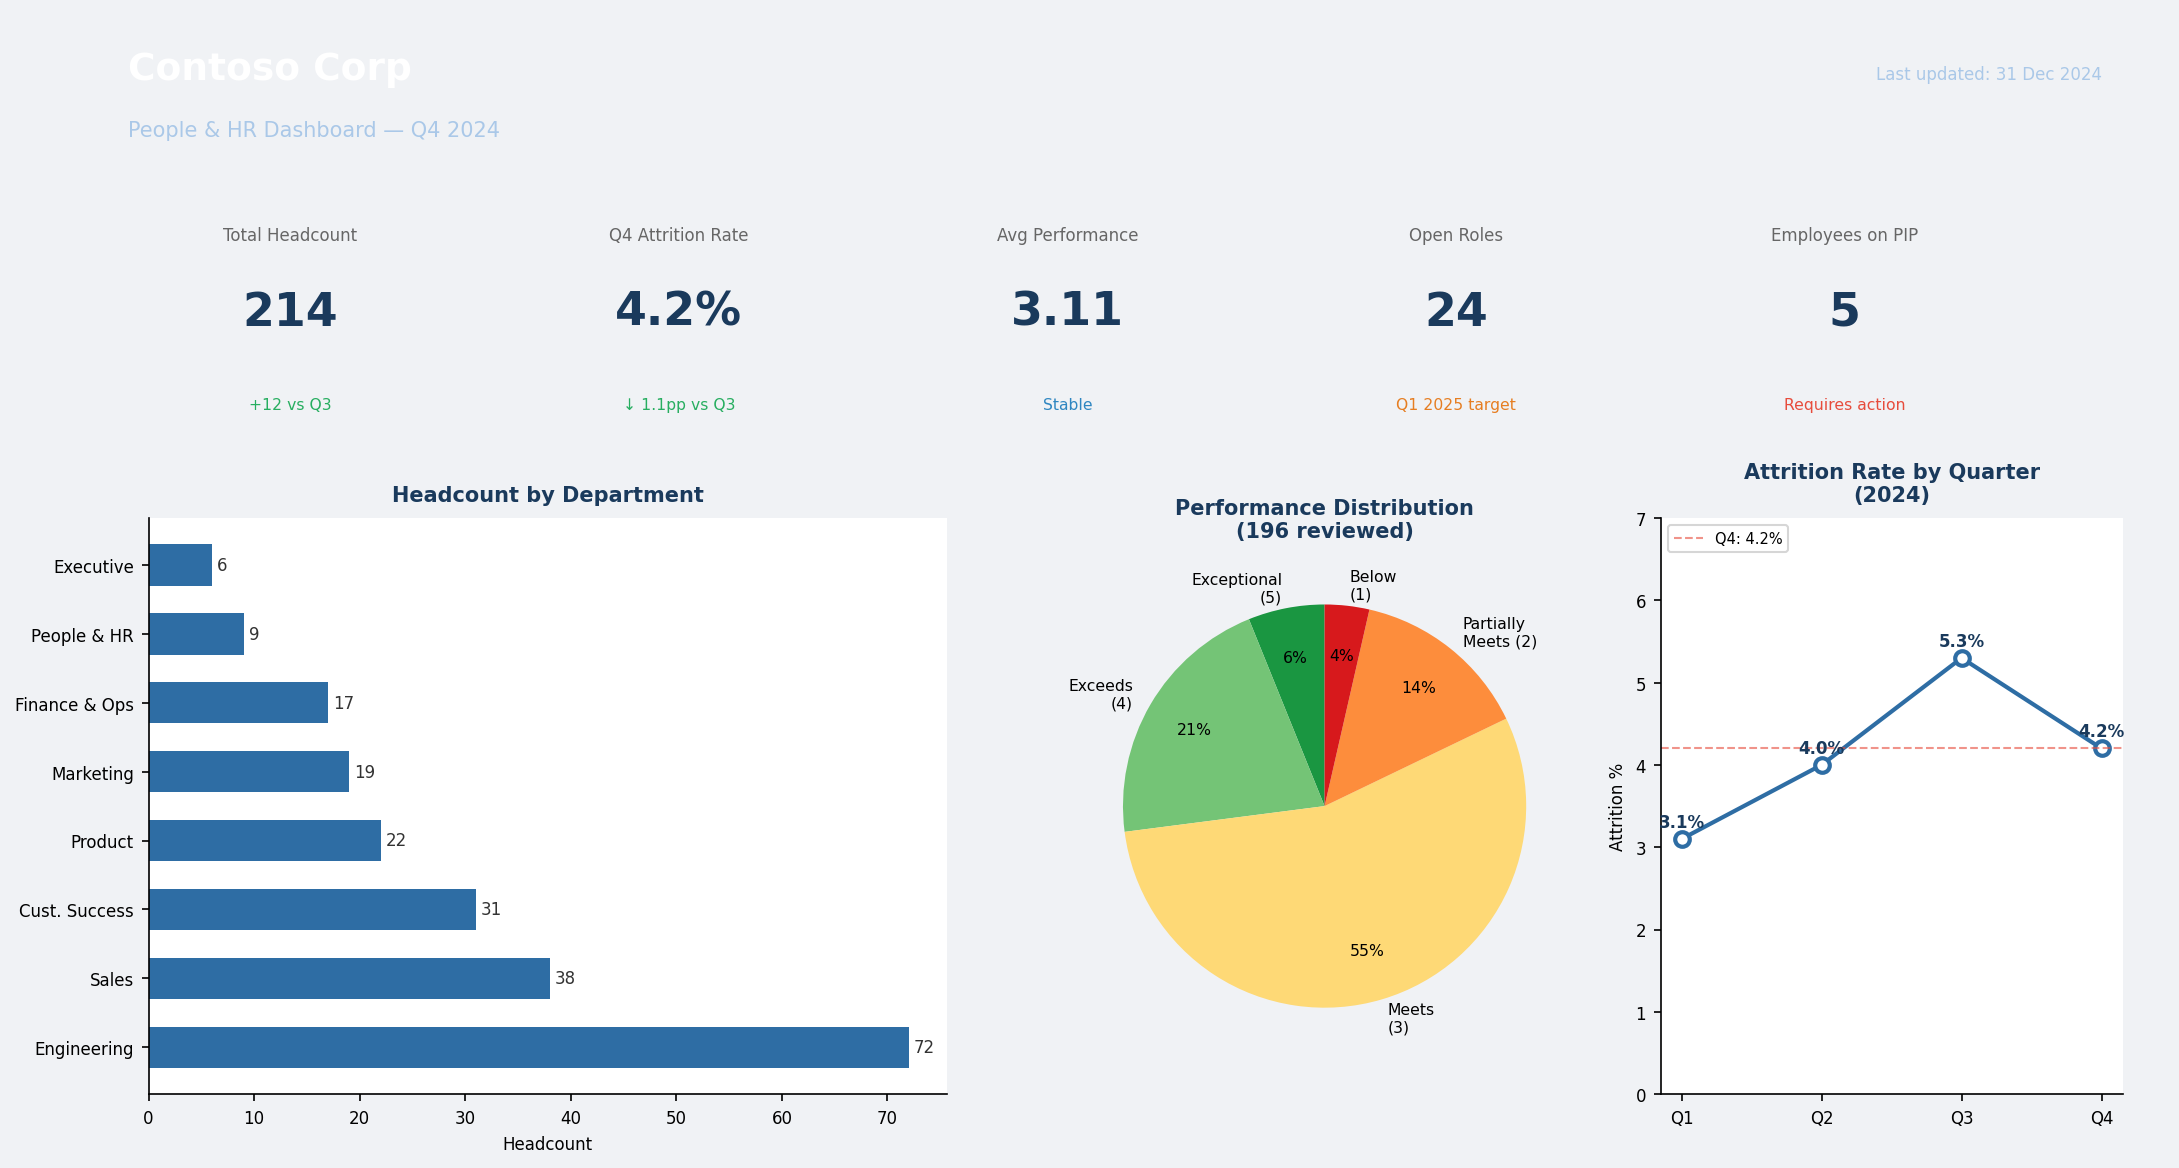

In [8]:
display(IPImage(data=DASHBOARD, width=750))


In [9]:
class DashboardKPIs(BaseModel):
    total_headcount: int
    q4_attrition_rate_percent: float
    average_performance_rating: float
    open_roles: int


response = chat(
    model=VISION_MODEL,
    messages=[{
        "role": "user",
        "content": (
            "Read the KPI cards at the top of this HR dashboard and extract: "
            "total headcount, Q4 attrition rate (as a percentage number only), "
            "average performance rating, and number of open roles."
        ),
        "images": [DASHBOARD],
    }],
    format=DashboardKPIs.model_json_schema(),
    options={"temperature": 0},
)

kpis = DashboardKPIs.model_validate_json(response.message.content)

print("Dashboard KPIs extracted:")
print(f"  Total headcount:          {kpis.total_headcount}")
print(f"  Q4 attrition rate:        {kpis.q4_attrition_rate_percent}%")
print(f"  Avg performance rating:   {kpis.average_performance_rating}")
print(f"  Open roles (Q1 2025):     {kpis.open_roles}")

# Ground-truth check (values embedded in generate_vision_assets.py)
checks = {
    "headcount == 214": kpis.total_headcount == 214,
    "attrition == 4.2%": kpis.q4_attrition_rate_percent == 4.2,
    "performance == 3.11": kpis.average_performance_rating == 3.11,
    "open roles == 24": kpis.open_roles == 24,
}
print()
for label, ok in checks.items():
    print(f"  {'✓' if ok else '✗'} {label}")

Dashboard KPIs extracted:
  Total headcount:          214
  Q4 attrition rate:        4.2%
  Avg performance rating:   3.11
  Open roles (Q1 2025):     24

  ✓ headcount == 214
  ✓ attrition == 4.2%
  ✓ performance == 3.11
  ✓ open roles == 24


## 4. Graceful error handling — non-vision model

Passing an image to a text-only model (e.g. `mistral:7b`) raises an error from Ollama.
In production code, you must detect this and surface a clear message to the caller.

In [10]:
import ollama


def vision_chat(model: str, prompt: str, image_bytes: bytes) -> str:
    """Send a vision request; return the response text or an informative error."""
    try:
        resp = chat(
            model=model,
            messages=[{
                "role": "user",
                "content": prompt,
                "images": [image_bytes],
            }],
            options={"temperature": 0},
        )
        return resp.message.content
    except ollama.ResponseError as exc:
        return (
            f"[ResponseError] Model '{model}' does not support vision.\n"
            f"  Use a multimodal model such as '{VISION_MODEL}'.\n"
            f"  Ollama error: {exc}"
        )
    except Exception as exc:
        return f"[Error] {type(exc).__name__}: {exc}"


prompt = "What is the total amount shown on this invoice?"

# Vision-capable model
print(f"── {VISION_MODEL} ──────────────────────────────────")
print(vision_chat(VISION_MODEL, prompt, INVOICE))

# Text-only model
if check_model_available(FALLBACK_MODEL):
    print(f"\n── {FALLBACK_MODEL} (text-only) ────────────────────────────")
    print(vision_chat(FALLBACK_MODEL, prompt, INVOICE))
else:
    print(f"\n'{FALLBACK_MODEL}' not available — skipping error demo.")

── gemma4:e4b ──────────────────────────────────
The total amount shown on this invoice is **£4,832.00**.

── mistral:7b (text-only) ────────────────────────────
 To determine the total amount on an invoice, you would typically look for a line item labeled "Total," "Grand Total," or similar. However, in the provided image, I don't see such a label. The invoice seems to be cut off at the bottom, so it might be there but not visible. If you can provide more information or a clearer image, I'd be happy to help further!
